Exploratory Data Analysis — Predicting Next Year’s Dashboard Color

This notebook performs exploratory data analysis (EDA) on Aspire Public Schools’ California School Dashboard data.
The goal of this project is to predict next year’s Dashboard color for each school and indicator, using historical performance data.

The dataset used here (aspire_all.csv) includes:
Aspire schools only
All Students group only
One row per school × indicator × year
Cleaned and standardized fields
This EDA explores:
distributions of key features
relationships between features
correlations
feature engineering opportunities
insights relevant to predicting next year’s color

## 1. Setup and Imports
In this section, I import the libraries needed for exploratory data analysis, including pandas for data manipulation and seaborn/matplotlib for visualization.

In [10]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

## 2. Load Dataset
I load the cleaned Aspire Dashboard dataset and explored the data using .info, .describe, and value_counts

In [11]:
#read cleaned dashboard data csv
df = pd.read_csv("aspire_all.csv")
df.head()

,cds,schoolname,indicator,year,studentgroup,currstatus,priorstatus,change,statuslevel,changelevel,color
0,1612590109819,Aspire Berkley Maynard Academy,chronic_absenteeism,2023,All Students,35.0,27.9,7.1,1,1,1
1,1612590118224,Aspire Golden State College Preparatory Academy,chronic_absenteeism,2023,All Students,40.1,40.8,-0.6,1,4,2
2,1612590128413,Aspire College Academy,chronic_absenteeism,2023,All Students,48.2,63.8,-15.6,1,5,3
3,1612590130666,Aspire Lionel Wilson College Preparatory Academy,chronic_absenteeism,2023,All Students,23.7,18.6,5.1,1,1,1
4,1612590130732,Aspire Triumph Technology Academy,chronic_absenteeism,2023,All Students,59.8,66.9,-7.1,1,5,3


Summary Statistics

In [13]:
#examine structure, data types, and summary statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cds           427 non-null    int64  
 1   schoolname    427 non-null    object 
 2   indicator     427 non-null    object 
 3   year          427 non-null    int64  
 4   studentgroup  427 non-null    object 
 5   currstatus    427 non-null    float64
 6   priorstatus   427 non-null    float64
 7   change        427 non-null    float64
 8   statuslevel   427 non-null    int64  
 9   changelevel   427 non-null    int64  
 10  color         427 non-null    int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 36.8+ KB


In [14]:
df.describe(include='all')

,cds,schoolname,indicator,year,studentgroup,currstatus,priorstatus,change,statuslevel,changelevel,color
count,4.270000e+02,427,427,427.000000,427,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000
unique,NaN,36,4,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Aspire Berkley Maynard Academy,suspension_rate,NaN,All Students,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,108,NaN,427,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.580187e+13,NaN,NaN,2024.000000,NaN,-23.654801,-23.060187,-0.598126,2.110070,3.391101,2.641686
std,1.574465e+13,NaN,NaN,0.819367,NaN,49.712061,51.223260,10.966614,1.240766,1.366678,1.188934
min,1.612590e+12,NaN,NaN,2023.000000,NaN,-148.800000,-148.800000,-44.600000,1.000000,1.000000,1.000000
25%,1.910199e+13,NaN,NaN,2023.000000,NaN,-62.800000,-64.650000,-6.100000,1.000000,2.000000,2.000000
50%,1.964733e+13,NaN,NaN,2024.000000,NaN,0.000000,0.000000,-0.700000,2.000000,4.000000,3.000000
75%,3.968676e+13,NaN,NaN,2025.000000,NaN,13.700000,14.050000,4.300000,3.000000,5.000000,3.000000


In [15]:
df['indicator'].value_counts()

indicator
suspension_rate        108
ela_sbac               107
math_sbac              107
chronic_absenteeism    105
Name: count, dtype: int64

In [16]:
df['year'].value_counts()

year
2023    143
2025    143
2024    141
Name: count, dtype: int64

## 5. Distribution of Numeric Features
Histograms help visualize the spread and shape of key numeric variables such as current status, prior status, and change. These distributions reveal skew, outliers, and general performance patterns.

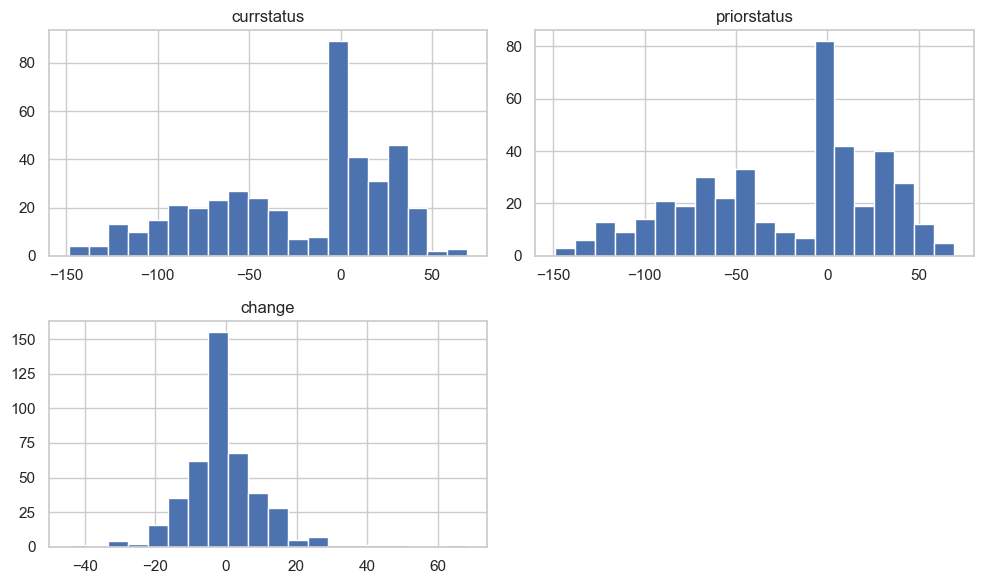

In [17]:
#plot histograms of current status, prio
numeric_cols = ['currstatus', 'priorstatus', 'change']
df[numeric_cols].hist(bins=20, figsize=(10,6))
plt.tight_layout()
plt.show()

### Interpretation
Currstatus and priorstatus show wide distributions centered near zero, indicating variation in school performance. Change is tightly centered around zero, suggesting most schools experience small year‑to‑year shifts.

## 6. Bivariate Relationships
Scatterplots help visualize how prior performance and year‑to‑year change relate to current status. These relationships indicate which features may be predictive.

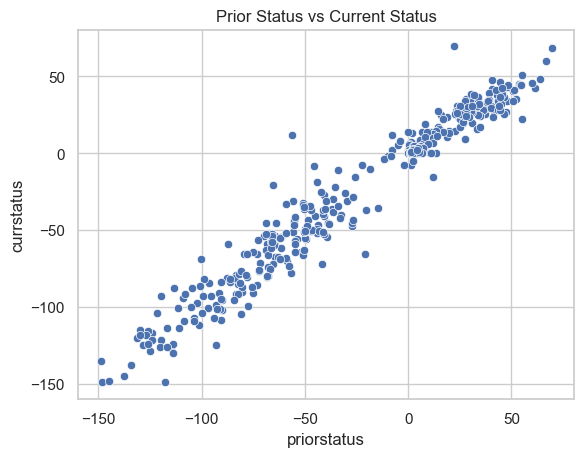

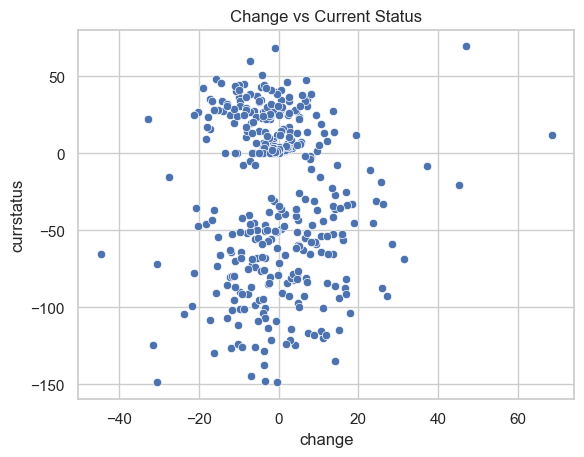

In [18]:
#inspect scatterplots
sns.scatterplot(data=df, x='priorstatus', y='currstatus')
plt.title("Prior Status vs Current Status")
plt.show()

sns.scatterplot(data=df, x='change', y='currstatus')
plt.title("Change vs Current Status")
plt.show()

### Interpretation
Prior status and current status show a strong linear relationship, indicating high year‑to‑year stability. Change is more dispersed, suggesting it adds nuance but is less predictive.

## 7. Subgroup Differences by Indicator
A boxplot of current status by indicator highlights differences across ELA, Math, Chronic Absenteeism, and Suspension. These differences help determine whether indicator type should be included as a feature.


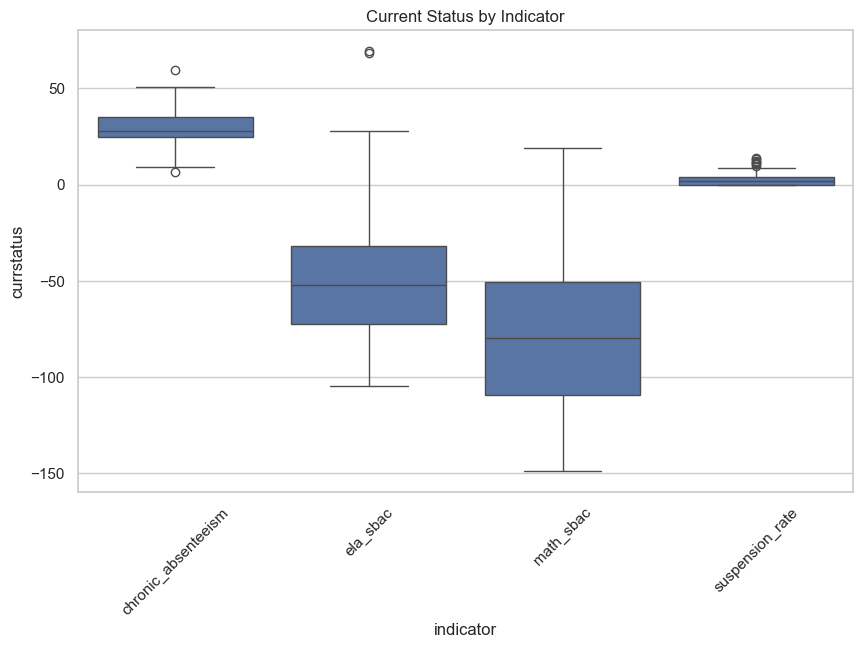

In [19]:
#inspect boxplots
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='indicator', y='currstatus')
plt.xticks(rotation=45)
plt.title("Current Status by Indicator")
plt.show()

### Interpretation
Indicators differ substantially in their performance distributions. Chronic absenteeism tends to have higher status values, while ELA and Math are lower and more tightly clustered. This confirms indicator type is an important categorical feature.

## 8. Correlation Analysis
A correlation heatmap quantifies the strength of relationships between numeric variables. This helps identify which features are most predictive of Dashboard color and whether multicollinearity is present.

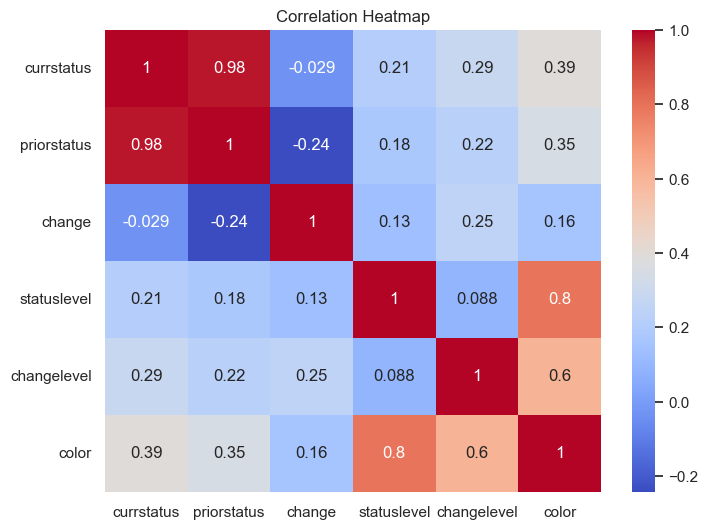

In [20]:
#inspect heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['currstatus','priorstatus','change','statuslevel','changelevel','color']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Interpretation
Statuslevel and changelevel show the strongest correlations with color, consistent with Dashboard rules. Currstatus and priorstatus are nearly perfectly correlated, indicating strong temporal stability.


## 9. Inferential Statistics
To test whether prior performance is associated with Dashboard color, I ran a Pearson correlation test between priorstatus and color.


In [22]:
from scipy.stats import pearsonr
pearsonr(df['priorstatus'], df['color'])

PearsonRResult(statistic=np.float64(0.34568079886872527), pvalue=np.float64(1.9820215022277218e-13))

### Interpretation
The correlation coefficient (0.3457) indicates a moderate positive relationship between prior status and Dashboard color. The extremely small p‑value (1.98 × 10⁻¹³) provides strong evidence against the null hypothesis, confirming that prior performance is statistically associated with Dashboard color.

## 10. Feature Engineering
To prepare the dataset for modeling, I created new features and encoded categorical variables. This includes:
- converting year to numeric
- creating a binary 'improved' feature
- one‑hot encoding the indicator variable
- retaining Dashboard‑derived features (statuslevel, changelevel)

In [21]:
# Convert year to numeric
df['year'] = df['year'].astype(int)

# Create a binary "improved" feature
df['improved'] = (df['change'] > 0).astype(int)

# One-hot encode indicator
df = pd.get_dummies(df, columns=['indicator'], drop_first=True)

df.head()

,cds,schoolname,year,studentgroup,currstatus,priorstatus,change,statuslevel,changelevel,color,improved,indicator_ela_sbac,indicator_math_sbac,indicator_suspension_rate
0,1612590109819,Aspire Berkley Maynard Academy,2023,All Students,35.0,27.9,7.1,1,1,1,1,False,False,False
1,1612590118224,Aspire Golden State College Preparatory Academy,2023,All Students,40.1,40.8,-0.6,1,4,2,0,False,False,False
2,1612590128413,Aspire College Academy,2023,All Students,48.2,63.8,-15.6,1,5,3,0,False,False,False
3,1612590130666,Aspire Lionel Wilson College Preparatory Academy,2023,All Students,23.7,18.6,5.1,1,1,1,1,False,False,False
4,1612590130732,Aspire Triumph Technology Academy,2023,All Students,59.8,66.9,-7.1,1,5,3,0,False,False,False


## 11. Key Findings
- Prior status and current status are almost perfectly correlated.
- Statuslevel and changelevel are the strongest predictors of color.
- Indicator type shows substantial subgroup differences.
- Change is noisier but still informative.
- The dataset is clean, complete, and modeling‑ready.

## 12. Conclusion
The EDA reveals clear relationships between performance metrics and Dashboard color. The dataset is well‑structured and contains strong predictive signals. The next step is to build classification models to predict next year’s Dashboard color using the engineered features identified in this notebook.